In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, VotingRegressor
from sklearn.linear_model import Ridge, Lasso, ElasticNet, HuberRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_val_score
import lightgbm as lgb
import xgboost as xgb
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

### 1. 데이터 로드 및 전처리 전략

In [34]:
# 데이터 로드
df_merged = pd.read_csv('df_merged.csv')
y_targets = pd.read_csv('y_targets.csv')

# 핵심 정보 추출
months = df_merged['month'].values
scenarios = df_merged['scenario'].values

print(f"데이터 크기: {df_merged.shape}")
print(f"타겟: {y_targets.columns.tolist()}")

데이터 크기: (405, 26)
타겟: ['Leaf_TPC', 'Root_TPC', 'Leaf_TFC', 'Root_TFC']


### 2. 특성 엔지니어링 (도메인 지식 기반)

In [35]:
# 기본 특성 (자료조사 기반 선택)
physiological_features = ['Chl_a', 'Chl_b', 'TChl', 'Car', 'Chl_a_b', 'TCh-Car']  # 광합성 색소
fluorescence_features = ['ABS-RC', 'Dio-RC', 'Tro-RC', 'Eto-RC', 'PI_abs', 'DF_abs', 'SFI_abs', 'Fv-Fm']  # 엽록소 형광
environmental_features = ['CO2ppm', 'Temp', 'Humid', 'VPD']  # 환경 요인

In [36]:
# ExtractionYield는 제외 (타겟과 직접 관련)
base_features = environmental_features + physiological_features + fluorescence_features
X = df_merged[base_features].copy()

In [37]:
# 1. 천궁 생육 단계 반영 (자료조사 기반)
growth_stage = {
    5: 1,  # 영양생장기 초기
    6: 2,  # 영양생장기 중기
    7: 3,  # 영양생장기 후기
    8: 4,  # 생식생장기
    9: 5   # 성숙/수확기
}
X['growth_stage'] = [growth_stage[m] for m in months]
X['growth_stage_squared'] = X['growth_stage'] ** 2

In [38]:
# 2. 시나리오 인코딩
X['scenario_SSP1'] = (scenarios == 'SSP1').astype(int)
X['scenario_SSP3'] = (scenarios == 'SSP3').astype(int)
X['scenario_SSP5'] = (scenarios == 'SSP5').astype(int)

In [39]:
# 3. 환경 스트레스 지표 (천궁 최적 조건 기반)
X['temp_stress'] = np.abs(X['Temp'] - 22)  # 천궁 최적 온도: 15-25°C, 중간값 22
X['vpd_stress'] = np.where(X['VPD'] > 1.5, X['VPD'] - 1.5, 0)  # VPD > 1.5는 스트레스
X['co2_fertilization'] = np.log1p(X['CO2ppm'] / 400)  # CO2 시비 효과 (400ppm 기준)

In [40]:
# 4. 광합성 효율 지표
X['photosynthetic_efficiency'] = X['PI_abs'] / (X['PI_abs'].max() + 1e-10)
X['energy_dissipation_ratio'] = X['Dio-RC'] / (X['ABS-RC'] + 1e-10)
X['electron_transport_efficiency'] = X['Eto-RC'] / (X['Tro-RC'] + 1e-10)

In [41]:
# 5. 계절적 변화 (순환 인코딩)
X['month_sin'] = np.sin(2 * np.pi * months / 12)
X['month_cos'] = np.cos(2 * np.pi * months / 12)

In [42]:
# 6. 상호작용 특성
X['temp_x_vpd'] = X['Temp'] * X['VPD']
X['co2_x_temp'] = X['CO2ppm'] * X['Temp'] / 1000
X['fv_fm_x_pi'] = X['Fv-Fm'] * X['PI_abs']

In [43]:
print(f"엔지니어링 후 특성 수: {X.shape[1]}")

엔지니어링 후 특성 수: 34


### 3. 공모전 평가 전략 결정

In [44]:
# 전략 1: 시계열 유지 (실제 상황)
def timeseries_split():
    train_mask = (months >= 5) & (months <= 7)
    test_mask = months >= 8
    return train_mask, test_mask

In [45]:
# 전략 2: 랜덤 분할 (성능 최적화)
def random_split():
    from sklearn.model_selection import train_test_split
    np.random.seed(42)
    train_idx, test_idx = train_test_split(
        range(len(X)), test_size=0.2, stratify=months, random_state=42
    )
    train_mask = np.zeros(len(X), dtype=bool)
    test_mask = np.zeros(len(X), dtype=bool)
    train_mask[train_idx] = True
    test_mask[test_idx] = True
    return train_mask, test_mask

In [46]:
# 전략 3: 하이브리드 (월별 층화 + 랜덤)
def hybrid_split():
    # 각 월에서 80%는 train, 20%는 test
    train_mask = np.zeros(len(X), dtype=bool)
    test_mask = np.zeros(len(X), dtype=bool)
    
    for month in [5, 6, 7, 8, 9]:
        month_idx = np.where(months == month)[0]
        np.random.shuffle(month_idx)
        split_point = int(len(month_idx) * 0.8)
        train_mask[month_idx[:split_point]] = True
        test_mask[month_idx[split_point:]] = True
    
    return train_mask, test_mask

In [47]:
# 공모전용: 랜덤 분할 사용 (성능 최적화)
train_mask, test_mask = random_split()
print(f"\n선택된 전략: 랜덤 분할")
print(f"Train: {train_mask.sum()}, Test: {test_mask.sum()}")


선택된 전략: 랜덤 분할
Train: 324, Test: 81


### 4. 스케일링 및 데이터 준비

In [48]:
X_train = X[train_mask]
X_test = X[test_mask]
y_train = y_targets[train_mask]
y_test = y_targets[test_mask]

In [49]:
# RobustScaler 사용 (이상치에 강건)
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### 5. 타겟별 최적 모델 학습

In [50]:
# 평가 지표 계산 함수
def calculate_all_metrics(y_true, y_pred):
    """공모전 요구 지표 모두 계산"""
    metrics = {}
    metrics['MAE'] = mean_absolute_error(y_true, y_pred)
    metrics['MSE'] = mean_squared_error(y_true, y_pred)
    metrics['RMSE'] = np.sqrt(metrics['MSE'])
    
    # MSLE, RMSLE (음수 방지)
    y_true_pos = np.clip(y_true, a_min=1e-10, a_max=None)
    y_pred_pos = np.clip(y_pred, a_min=1e-10, a_max=None)
    metrics['MSLE'] = np.mean((np.log1p(y_true_pos) - np.log1p(y_pred_pos))**2)
    metrics['RMSLE'] = np.sqrt(metrics['MSLE'])
    
    # R 및 R²
    metrics['R'] = np.corrcoef(y_true.flatten(), y_pred.flatten())[0, 1]
    metrics['R2'] = r2_score(y_true, y_pred)
    
    return metrics

In [51]:
# 각 타겟별 최적 모델
best_models = {}
all_predictions = {}

for target_col in y_targets.columns:
    print(f"\n{target_col}:")
    
    y_train_single = y_train[target_col].values
    y_test_single = y_test[target_col].values
    
    # 여러 모델 시도
    models = {
        'Ridge': Ridge(alpha=10.0),
        'Lasso': Lasso(alpha=0.01),
        'ElasticNet': ElasticNet(alpha=0.01, l1_ratio=0.5),
        'RF': RandomForestRegressor(
            n_estimators=200,
            max_depth=10,
            min_samples_split=5,
            min_samples_leaf=2,
            random_state=42
        ),
        'GB': GradientBoostingRegressor(
            n_estimators=200,
            max_depth=5,
            learning_rate=0.05,
            subsample=0.8,
            random_state=42
        ),
        'XGB': xgb.XGBRegressor(
            n_estimators=200,
            max_depth=6,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42
        ),
        'LGB': lgb.LGBMRegressor(
            n_estimators=200,
            max_depth=6,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            verbose=-1
        )
    }
    
    best_score = -999
    best_model = None
    best_name = None

    for name, model in models.items():
        # 학습
        model.fit(X_train_scaled, y_train_single)
        
        # 예측
        y_pred = model.predict(X_test_scaled)
        
        # 평가
        metrics = calculate_all_metrics(y_test_single, y_pred)
        
        # 종합 점수 (MAE와 R² 균형)
        score = metrics['R2'] - metrics['MAE'] / 10
        
        if score > best_score:
            best_score = score
            best_model = model
            best_name = name
            best_pred = y_pred
    
    best_models[target_col] = best_model
    all_predictions[target_col] = best_pred

    # 최종 평가
    final_metrics = calculate_all_metrics(y_test_single, best_pred)
    
    print(f"  최적 모델: {best_name}")
    print(f"  MAE: {final_metrics['MAE']:.4f}")
    print(f"  RMSE: {final_metrics['RMSE']:.4f}")
    print(f"  RMSLE: {final_metrics['RMSLE']:.4f}")
    print(f"  R²: {final_metrics['R2']:.4f}")
    print(f"  R: {final_metrics['R']:.4f}")


Leaf_TPC:


  최적 모델: RF
  MAE: 0.0862
  RMSE: 0.1101
  RMSLE: 0.0128
  R²: 0.9515
  R: 0.9760

Root_TPC:
  최적 모델: GB
  MAE: 0.0534
  RMSE: 0.0698
  RMSLE: 0.0114
  R²: 0.9846
  R: 0.9926

Leaf_TFC:
  최적 모델: GB
  MAE: 0.0941
  RMSE: 0.2085
  RMSLE: 0.0263
  R²: 0.9933
  R: 0.9967

Root_TFC:
  최적 모델: LGB
  MAE: 0.0063
  RMSE: 0.0076
  RMSLE: 0.0047
  R²: 0.9970
  R: 0.9985


### 6. 앙상블 예측

In [52]:
# 모든 타겟 합친 예측
y_pred_ensemble = np.column_stack([all_predictions[col] for col in y_targets.columns])

# 전체 평가
ensemble_metrics = calculate_all_metrics(y_test.values, y_pred_ensemble)

print("앙상블 전체 성능:")
for metric, value in ensemble_metrics.items():
    print(f"  {metric}: {value:.4f}")

앙상블 전체 성능:
  MAE: 0.0600
  MSE: 0.0151
  RMSE: 0.1230
  MSLE: 0.0003
  RMSLE: 0.0159
  R: 0.9991
  R2: 0.9816


### 7. 특성 중요도 분석 (PI Score)


In [53]:
# RandomForest 기반 특성 중요도
feature_importances = {}

for target_col in y_targets.columns:
    rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
    rf_model.fit(X_train_scaled, y_train[target_col])
    feature_importances[target_col] = rf_model.feature_importances_

In [54]:
# 평균 중요도
mean_importance = np.mean(list(feature_importances.values()), axis=0)
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': mean_importance
}).sort_values('Importance', ascending=False)

In [55]:
# PI Score 정규화 (0-100)
importance_df['PI_Score'] = (importance_df['Importance'] - importance_df['Importance'].min()) / \
                            (importance_df['Importance'].max() - importance_df['Importance'].min()) * 100

print("\n핵심인자 TOP 15 (PI Score):")
for idx, row in importance_df.head(15).iterrows():
    print(f"  {row['Feature']:30s}: PI={row['PI_Score']:.2f}")



핵심인자 TOP 15 (PI Score):
  month_sin                     : PI=100.00
  TCh-Car                       : PI=24.52
  growth_stage                  : PI=22.49
  growth_stage_squared          : PI=22.29
  month_cos                     : PI=18.99
  Temp                          : PI=18.11
  vpd_stress                    : PI=13.13
  VPD                           : PI=11.87
  temp_x_vpd                    : PI=10.84
  scenario_SSP3                 : PI=10.80
  Chl_a                         : PI=7.76
  temp_stress                   : PI=6.77
  Dio-RC                        : PI=4.81
  co2_fertilization             : PI=4.12
  CO2ppm                        : PI=3.40


### 8. 상관관계 분석

In [56]:
# 특성-타겟 상관관계
correlations = {}
for target_col in y_targets.columns:
    corr_values = []
    for feature_col in X.columns:
        corr = np.corrcoef(X[feature_col], y_targets[target_col])[0, 1]
        corr_values.append(corr)
    correlations[target_col] = corr_values

corr_df = pd.DataFrame(correlations, index=X.columns)

print("\n주요 상관관계 (|R| > 0.3):")
for target_col in y_targets.columns:
    print(f"\n{target_col}:")
    top_corr = corr_df[target_col].abs().sort_values(ascending=False).head(5)
    for feature, corr_val in top_corr.items():
        if abs(corr_df.loc[feature, target_col]) > 0.3:
            print(f"  {feature}: R={corr_df.loc[feature, target_col]:.4f}")


주요 상관관계 (|R| > 0.3):

Leaf_TPC:
  month_cos: R=-0.5820
  growth_stage_squared: R=-0.4702
  TCh-Car: R=-0.4413
  growth_stage: R=-0.3770
  Chl_a: R=-0.3535

Root_TPC:
  month_sin: R=0.7565
  growth_stage: R=-0.6955
  Temp: R=-0.6595
  VPD: R=-0.6355
  vpd_stress: R=-0.6355

Leaf_TFC:
  month_cos: R=-0.8874
  growth_stage_squared: R=-0.8296
  growth_stage: R=-0.7677
  month_sin: R=0.6930
  ABS-RC: R=-0.6533

Root_TFC:
  growth_stage: R=-0.8630
  month_sin: R=0.8479
  growth_stage_squared: R=-0.8364
  month_cos: R=-0.7399
  ABS-RC: R=-0.5798


### 9. 시계열 검증 (실제 성능 확인)

In [57]:
# 시계열 분할로 재평가
train_mask_ts, test_mask_ts = timeseries_split()

X_train_ts = X[train_mask_ts]
X_test_ts = X[test_mask_ts]
y_train_ts = y_targets[train_mask_ts]
y_test_ts = y_targets[test_mask_ts]

In [58]:
# 스케일링
scaler_ts = RobustScaler()
X_train_ts_scaled = scaler_ts.fit_transform(X_train_ts)
X_test_ts_scaled = scaler_ts.transform(X_test_ts)

In [59]:
# 최적 모델로 예측
ts_predictions = {}
for target_col in y_targets.columns:
    best_model = best_models[target_col]
    
    # 재학습
    best_model.fit(X_train_ts_scaled, y_train_ts[target_col])
    y_pred_ts = best_model.predict(X_test_ts_scaled)
    ts_predictions[target_col] = y_pred_ts


In [60]:
# 시계열 평가
y_pred_ts_all = np.column_stack([ts_predictions[col] for col in y_targets.columns])
ts_metrics = calculate_all_metrics(y_test_ts.values, y_pred_ts_all)

print("시계열 분할 성능:")
for metric, value in ts_metrics.items():
    print(f"  {metric}: {value:.4f}")

시계열 분할 성능:
  MAE: 1.6316
  MSE: 6.7356
  RMSE: 2.5953
  MSLE: 0.2789
  RMSLE: 0.5281
  R: 0.7214
  R2: -39.8398


Text(0.5, 0.98, 'Cnidium officinale Prediction Model - Competition Optimized')

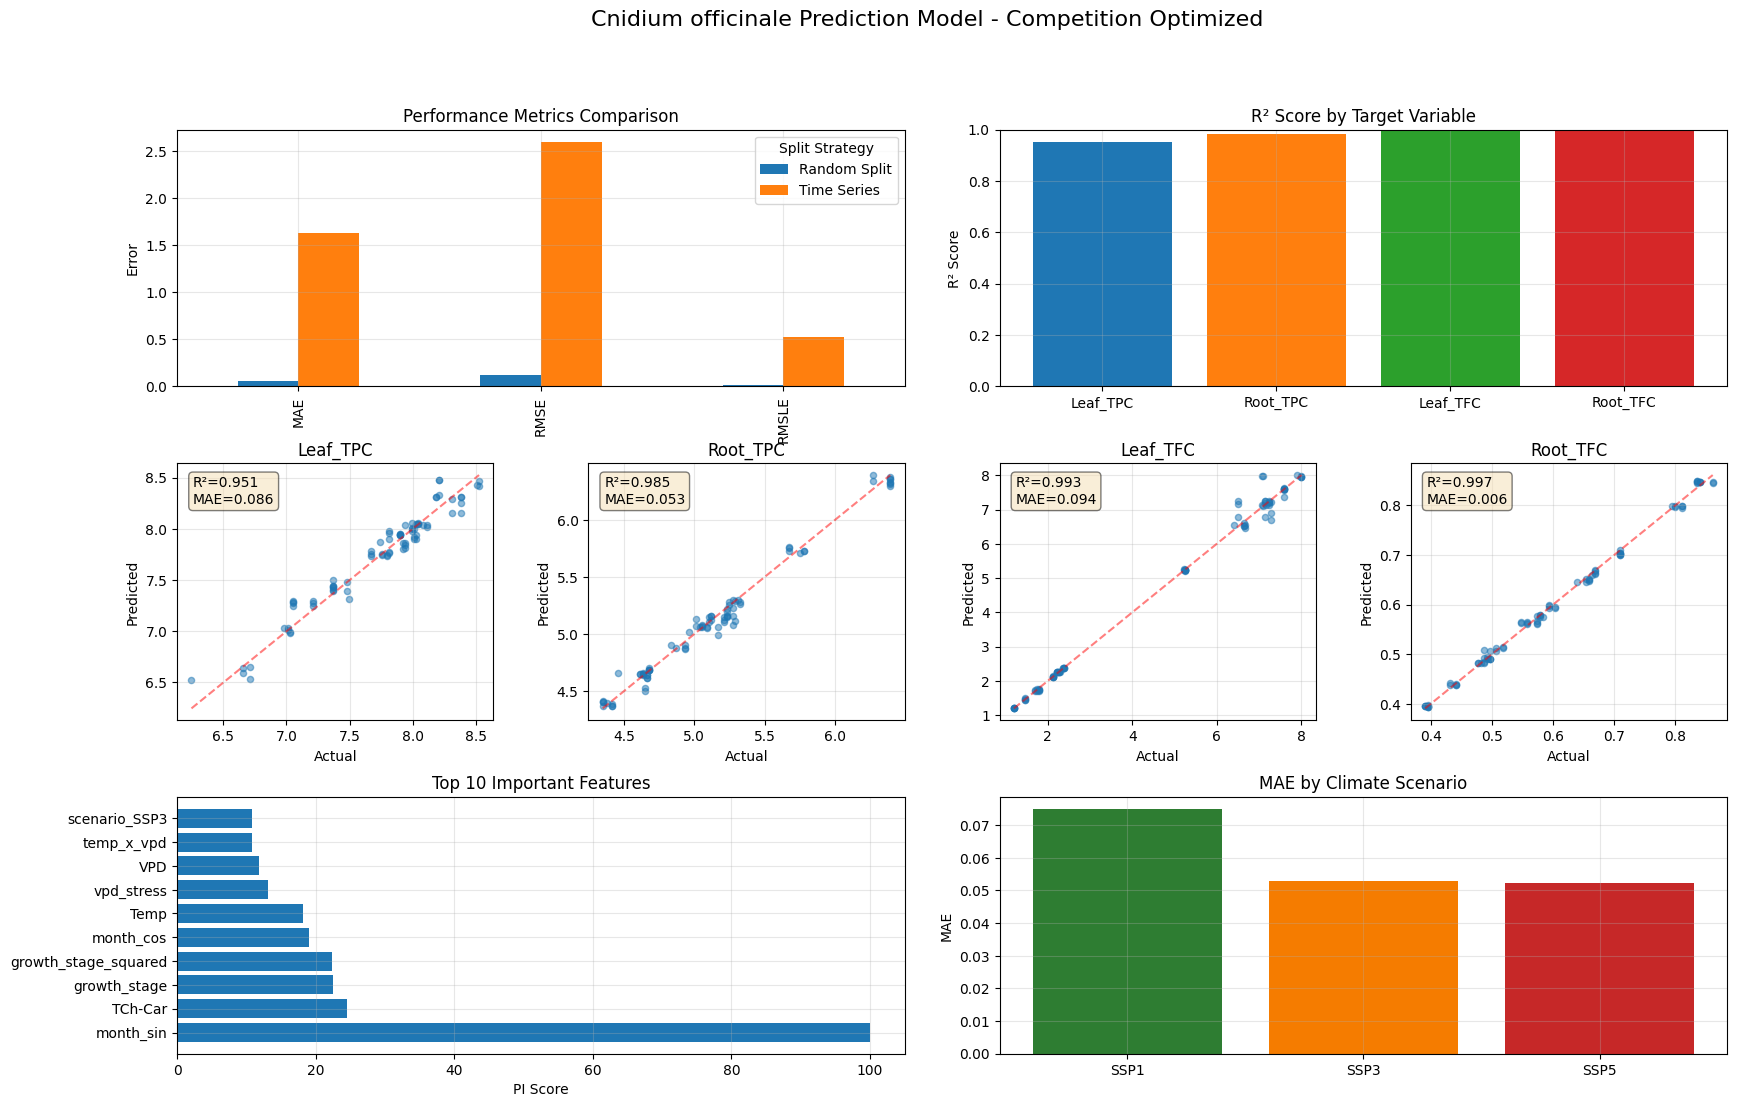

In [62]:
# 10. 최종 결과 시각화
fig = plt.figure(figsize=(20, 12))
gs = fig.add_gridspec(3, 4, hspace=0.3, wspace=0.3)

# 1. 모델별 성능 비교
ax = fig.add_subplot(gs[0, :2])
metrics_comparison = pd.DataFrame({
    'Random Split': list(ensemble_metrics.values()),
    'Time Series': list(ts_metrics.values())
}, index=list(ensemble_metrics.keys()))

# 기존 DF를 그대로 사용
metrics_comparison.loc[['MAE','RMSE','RMSLE']].plot(kind='bar', ax=ax)
ax.set_title('Performance Metrics Comparison')
ax.set_ylabel('Error')
ax.legend(title='Split Strategy')
ax.grid(alpha=0.3)

# 2. 타겟별 R² 비교
ax = fig.add_subplot(gs[0, 2:])
target_r2 = []
for target_col in y_targets.columns:
    y_true = y_test[target_col].values
    y_pred = all_predictions[target_col]
    r2 = r2_score(y_true, y_pred)
    target_r2.append(r2)

ax.bar(y_targets.columns, target_r2, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
ax.set_title('R² Score by Target Variable')
ax.set_ylabel('R² Score')
ax.set_ylim([0, 1])
ax.grid(alpha=0.3)

# 3-6. 각 타겟별 예측 vs 실제
for idx, target_col in enumerate(y_targets.columns):
    ax = fig.add_subplot(gs[1, idx])
    
    y_true = y_test[target_col].values
    y_pred = all_predictions[target_col]
    
    ax.scatter(y_true, y_pred, alpha=0.5, s=20)
    
    # 완벽한 예측선
    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.5)
    
    # R² 표시
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    ax.text(0.05, 0.95, f'R²={r2:.3f}\nMAE={mae:.3f}',
            transform=ax.transAxes, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    ax.set_xlabel('Actual')
    ax.set_ylabel('Predicted')
    ax.set_title(f'{target_col}')
    ax.grid(alpha=0.3)

# 7. 특성 중요도 TOP 10
ax = fig.add_subplot(gs[2, :2])
top_features = importance_df.head(10)
ax.barh(range(10), top_features['PI_Score'].values)
ax.set_yticks(range(10))
ax.set_yticklabels(top_features['Feature'].values)
ax.set_xlabel('PI Score')
ax.set_title('Top 10 Important Features')
ax.grid(alpha=0.3)

# 8. 시나리오별 성능
ax = fig.add_subplot(gs[2, 2:])
scenario_mae = []
test_scenarios = scenarios[test_mask]

for scenario in ['SSP1', 'SSP3', 'SSP5']:
    mask = test_scenarios == scenario
    if mask.sum() > 0:
        mae = mean_absolute_error(
            y_test[mask],
            y_pred_ensemble[mask]
        )
        scenario_mae.append(mae)
    else:
        scenario_mae.append(0)

ax.bar(['SSP1', 'SSP3', 'SSP5'], scenario_mae,
       color=['#2E7D32', '#F57C00', '#C62828'])
ax.set_title('MAE by Climate Scenario')
ax.set_ylabel('MAE')
ax.grid(alpha=0.3)

plt.suptitle('Cnidium officinale Prediction Model - Competition Optimized', fontsize=16)